# 22 — Gateway Decision Analysis — BPIC17: LSTM Surrogate vs Ground Truth

For each **decision point** (gateway) in the process, trains two decision trees
on identical prefixes:

1. **LSTM Surrogate** — target = model's predicted next activity
2. **Ground Truth** — target = actual next activity from the event log

Compares rules, feature importances, and agreement to reveal whether the LSTM
has learned the same decision logic that exists in the data.

In [14]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [15]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from src.interpretability.surrogate.c45_tree import C45Classifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'BPIC_2017_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = (_current / 'src' / 'notebooks' / 'training_variational_dropout'
              / 'BPIC17' / 'BPIC_2017_full_grad_norm_new_4layer.pkl')
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'concept:name'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- Feature indices (BPIC17) ---
ACT_IDX = decoder.cat_features.index('concept:name')       # 0
RES_IDX = decoder.cat_features.index('org:resource')        # 2
LC_IDX = decoder.cat_features.index('lifecycle:transition')  # 4
LG_IDX = decoder.cat_features.index('case:LoanGoal')        # 5
AT_IDX = decoder.cat_features.index('case:ApplicationType')  # 6

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')
amount_num_idx = decoder.num_features.index('case:RequestedAmount')
credit_num_idx = decoder.num_features.index('CreditScore')
day_num_idx = decoder.num_features.index('day_in_week')

print(f'Act={ACT_IDX}, Res={RES_IDX}, LC={LC_IDX}, LG={LG_IDX}, AT={AT_IDX}')
print(f'elapsed={elapsed_num_idx}, event={event_num_idx}, amount={amount_num_idx}, '
      f'credit={credit_num_idx}, day={day_num_idx}')
print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

Dataset: 253196 sequences, 9 cat, 9 num, seq_len=96
Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 1

## Build DFG and identify qualifying gateways

A gateway is an activity with more than one observed successor. We filter to
gateways with at least `MIN_CASES` prefixes and at least two branches with
`MIN_BRANCH` cases each, so the decision trees have enough data.

In [16]:
MIN_CASES = 50       # minimum prefixes at this gateway
MIN_BRANCH = 10      # minimum cases per branch (need at least 2 branches above this)
MIN_SAMPLES_LEAF = 20

ACTIVITY_WINDOW = 40    # number of recent activities to include as positional features

# --- Collect unique cases (longest trace per case_id) ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'{len(cases)} unique cases')

# --- Build DFG ---
dfg = {}
successors_map = {}

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'\nDecision points ({len(decision_points)}):')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c}, {c/total*100:.0f}%)' for s, c in
                         sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total} cases): {branches}')

6301 unique cases

Decision points (22):
  W_Validate application (39038 cases): W_Validate application (23032, 59%), A_Validating (7656, 20%), W_Call incomplete files (4515, 12%), O_Accepted (2316, 6%), A_Denied (652, 2%), O_Cancelled (604, 2%), O_Returned (185, 0%), W_Assess potential fraud (48, 0%), O_Create Offer (19, 0%), A_Cancelled (11, 0%)
  W_Call after offers (36452 cases): W_Call after offers (23236, 64%), A_Complete (6270, 17%), W_Validate application (4343, 12%), A_Cancelled (1729, 5%), O_Create Offer (787, 2%), O_Cancelled (51, 0%), A_Denied (17, 0%), W_Shortened completion  (7, 0%), O_Sent (mail and online) (6, 0%), W_Assess potential fraud (5, 0%), O_Accepted (1, 0%)
  W_Call incomplete files (32395 cases): W_Call incomplete files (22646, 70%), A_Incomplete (4512, 14%), W_Validate application (3313, 10%), O_Accepted (909, 3%), O_Create Offer (377, 1%), O_Cancelled (268, 1%), A_Cancelled (176, 1%), O_Returned (153, 0%), A_Denied (34, 0%), W_Assess potential fraud (3, 0%)

## Collect per-gateway prefixes

For each qualifying gateway, find every prefix that ends at that activity (where
a real next activity exists). Extract both the actual next activity and the
LSTM's prediction, plus engineered features for the surrogate trees.

In [ ]:
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract engineered aggregate features from a single BPIC17 prefix."""
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    acts = act_tensor[start:end]

    # Trailing repetitions of last activity
    last_act = acts[-1].item()
    repeated = 1
    for k in range(len(acts) - 2, -1, -1):
        if acts[k].item() == last_act:
            repeated += 1
        else:
            break

    # Time features (inverse-transformed)
    total_elapsed = decoder.decode_numerical_value(
        'case_elapsed_time', num_tuple[elapsed_num_idx][end - 1].item())
    last_event_dur = decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][end - 1].item())
    event_durs = [decoder.decode_numerical_value(
        'event_elapsed_time', num_tuple[event_num_idx][j].item())
        for j in range(start, end)]
    mean_event_dur = float(np.mean(event_durs))

    # Resource features
    res_tensor = cat_tuple[RES_IDX]
    resources = res_tensor[start:end].tolist()
    n_unique_res = len(set(resources))

    # BPIC17-specific numerical features
    requested_amount = decoder.decode_numerical_value(
        'case:RequestedAmount', num_tuple[amount_num_idx][end - 1].item())
    credit_score = decoder.decode_numerical_value(
        'CreditScore', num_tuple[credit_num_idx][end - 1].item())
    day_in_week = decoder.decode_numerical_value(
        'day_in_week', num_tuple[day_num_idx][end - 1].item())

    result = {
        'prefix_length': prefix_len,
        'last_activity': decoder.decode_categorical_value(ACT_IDX, acts[-1].item()),
        'first_activity': decoder.decode_categorical_value(ACT_IDX, acts[0].item()),
        'n_unique_activities': len(set(acts.tolist())),
        'last_activity_repeated': repeated,
        'total_elapsed_time': total_elapsed,
        'last_event_duration': last_event_dur,
        'mean_event_duration': mean_event_dur,
        'last_resource': decoder.decode_categorical_value(RES_IDX, res_tensor[end - 1].item()),
        'n_unique_resources': n_unique_res,
        'loan_goal': decoder.decode_categorical_value(LG_IDX, cat_tuple[LG_IDX][end - 1].item()),
        'application_type': decoder.decode_categorical_value(AT_IDX, cat_tuple[AT_IDX][end - 1].item()),
        'requested_amount': requested_amount,
        'credit_score': credit_score,
        'last_lifecycle': decoder.decode_categorical_value(LC_IDX, cat_tuple[LC_IDX][end - 1].item()),
        'day_in_week': day_in_week,
    }
# Positional activity features: last WINDOW_SIZE activities in the prefix
    for w in range(1, ACTIVITY_WINDOW + 1):
        pos = len(acts) - w
        if pos >= 0:
            result[f'act_pos_{-w}'] = decoder.decode_categorical_value(ACT_IDX, acts[pos].item())
        else:
            result[f'act_pos_{-w}'] = '<pad>'

    return result


# --- Collect gateway data ---
gateway_data = {}  # gateway_name -> {X, y_lstm, y_actual, cat_list, num_list}

for gateway_act, succs in decision_points.items():
    # Check if gateway qualifies
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows = []
    actual_labels = []
    cat_list = []
    num_list = []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        # Strip trailing EOS
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        # Find all positions where activity == gateway and next activity exists
        for k in range(useful_len - 1):
            act_idx_val = acts[k].item()
            if activity_names[act_idx_val] != gateway_act:
                continue

            next_act_name = activity_names[acts[k + 1].item()]
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            # Build padded prefix tensors
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    # Batch-predict LSTM labels
    N = len(X)
    cat_batch = [
        torch.stack([cat_list[i][ci] for i in range(N)])
        for ci in range(n_cat)
    ]
    num_stacked = torch.stack([
        torch.stack(num_list[i], dim=-1) for i in range(N)
    ])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
    }

    # Report
    n_branches_actual = len(set(y_actual))
    n_branches_lstm = len(set(y_lstm))
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'\n{gateway_act}: {N} prefixes, '
          f'{n_branches_actual} actual branches, {n_branches_lstm} LSTM branches, '
          f'LSTM accuracy={lstm_acc:.3f}')
    print(f'  Actual distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_actual, return_counts=True))))
    print(f'  LSTM   distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_lstm, return_counts=True))))

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')


A_Create Application: 6301 prefixes, 3 actual branches, 2 LSTM branches, LSTM accuracy=0.236
  Actual distribution: A_Concept (671), A_Submitted (4074), W_Complete application (1556)
  LSTM   distribution: W_Complete application (2148), W_Handle leads (4153)

W_Handle leads: 9382 prefixes, 3 actual branches, 3 LSTM branches, LSTM accuracy=0.868
  Actual distribution: W_Assess potential fraud (4), W_Complete application (4074), W_Handle leads (5304)
  LSTM   distribution: A_Concept (25), W_Complete application (5269), W_Handle leads (4088)

W_Complete application: 29857 prefixes, 12 actual branches, 6 LSTM branches, LSTM accuracy=0.721
  Actual distribution: A_Accepted (4435), A_Cancelled (7), A_Concept (5630), A_Denied (2), O_Cancelled (12), O_Create Offer (321), O_Sent (mail and online) (120), O_Sent (online only) (4), W_Assess potential fraud (4), W_Call after offers (6270), W_Complete application (13044), W_Shortened completion  (8)
  LSTM   distribution: A_Cancelled (1), A_Concept

## Train surrogate and ground truth trees per gateway

For each gateway, the same stratified 60/20/20 train/validation/test
split is used for both trees so they are fit on identical training data,
selected on identical validation data, and evaluated on identical
held-out test data. Depth is swept on the validation set and the
shallowest tree within 2% of the best validation score is selected.
Final fidelity, accuracy, and agreement metrics are reported on the
held-out test set.

In [ ]:
def select_best_depth(X_train, y_train, X_val, y_val, cat_features,
                      depths=(3, 4, 5, 6, 8)):
    """Sweep depths on validation set; prefer shallowest within 2% of best."""
    results = []
    for depth in depths:
        clf = C45Classifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train, categorical_features=cat_features)
        train_sc = clf.score(X_train, y_train)
        val_sc = clf.score(X_val, y_val)
        results.append({'depth': depth, 'train': train_sc, 'val': val_sc, 'clf': clf})

    best_idx = 0
    best_val = results[0]['val']
    for i in range(1, len(results)):
        if results[i]['val'] > best_val + 0.02:
            best_idx = i
            best_val = results[i]['val']
    return results[best_idx]['clf'], results


# --- Train trees for each gateway ---
gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    # Identify categorical columns (object dtype)
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    # --- Three-way split: 60% train / 20% validation / 20% test ---
    # First split: 80% trainval / 20% test (held out for final metrics)
    try:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2, random_state=42)

    # Second split: 75% of trainval = 60% total for training, 25% of trainval = 20% total for validation
    try:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25,
                             random_state=42, stratify=y_actual_tv)
    except ValueError:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25, random_state=42)

    feature_names = list(X.columns)

    # Train C4.5 trees on train set, select depth on validation set
    clf_lstm, lstm_sweep = select_best_depth(
        X_train, y_lstm_train, X_val, y_lstm_val, cat_cols)
    clf_gt, gt_sweep = select_best_depth(
        X_train, y_actual_train, X_val, y_actual_val, cat_cols)

    # --- Final metrics on held-out TEST set ---
    surrogate_fidelity = clf_lstm.score(X_test, y_lstm_test)
    gt_accuracy = clf_gt.score(X_test, y_actual_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()
    agreement = (clf_lstm.predict(X_test) == clf_gt.predict(X_test)).mean()

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'cat_cols': cat_cols,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_lstm_train': y_lstm_train, 'y_lstm_val': y_lstm_val, 'y_lstm_test': y_lstm_test,
        'y_actual_train': y_actual_train, 'y_actual_val': y_actual_val, 'y_actual_test': y_actual_test,
        'surrogate_fidelity': surrogate_fidelity,
        'gt_accuracy': gt_accuracy,
        'lstm_accuracy': lstm_accuracy,
        'agreement': agreement,
        'n_cases': len(X),
        'lstm_sweep': lstm_sweep, 'gt_sweep': gt_sweep,
    }

    print(f'\n{"=" * 70}')
    print(f'Gateway: {gateway_act} ({len(X)} prefixes: '
          f'{len(X_train)} train / {len(X_val)} val / {len(X_test)} test)')
    print(f'  LSTM accuracy at gateway:     {lstm_accuracy:.3f}')
    print(f'  Surrogate fidelity (vs LSTM): {surrogate_fidelity:.3f}  '
          f'(depth={clf_lstm.get_depth()}, leaves={clf_lstm.get_n_leaves()})')
    print(f'  Ground truth tree accuracy:   {gt_accuracy:.3f}  '
          f'(depth={clf_gt.get_depth()}, leaves={clf_gt.get_n_leaves()})')
    print(f'  Agreement (surrogate vs GT):  {agreement:.3f}')

## Summary table

In [ ]:
summary_rows = []
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_
    top_lstm = fn[np.argmax(imp_lstm)]
    top_gt = fn[np.argmax(imp_gt)]

    summary_rows.append({
        'Gateway': gateway_act,
        '#Cases': gr['n_cases'],
        '#Branches (actual)': len(set(gr['y_actual_train']) | set(gr['y_actual_test'])),
        'LSTM Accuracy': f'{gr["lstm_accuracy"]:.3f}',
        'Surrogate Fidelity': f'{gr["surrogate_fidelity"]:.3f}',
        'GT Tree Accuracy': f'{gr["gt_accuracy"]:.3f}',
        'Agreement': f'{gr["agreement"]:.3f}',
        'Top LSTM Feature': top_lstm,
        'Top GT Feature': top_gt,
        'Same Top Feature': top_lstm == top_gt,
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Gateway,#Cases,#Branches (actual),LSTM Accuracy,Surrogate Fidelity,GT Tree Accuracy,Agreement,Top LSTM Feature,Top GT Feature,Same Top Feature
0,A_Create Application,6301,3,0.236,0.817,0.829,0.076,application_type,application_type,True
1,W_Handle leads,9382,3,0.864,0.997,0.944,0.915,prefix_length,mean_event_duration,False
2,W_Complete application,29857,12,0.722,0.909,0.834,0.856,last_event_duration,n_unique_activities,False
3,A_Concept,6301,3,0.704,1.000,0.911,0.758,prefix_length,mean_event_duration,False
4,A_Accepted,6300,3,0.936,0.989,0.947,1.000,total_elapsed_time,last_event_duration,False
5,O_Created,8648,10,0.804,0.964,0.832,0.949,n_unique_activities,n_unique_activities,True
6,O_Sent (mail and online),7975,10,0.870,0.895,0.864,0.847,prefix_length,prefix_length,True
7,W_Call after offers,36452,11,0.906,0.762,0.834,0.714,last_activity_repeated,last_event_duration,False
8,A_Complete,6270,8,0.969,1.000,0.969,1.000,prefix_length,total_elapsed_time,False
9,A_Cancelled,2115,4,0.780,0.863,0.983,0.773,mean_event_duration,last_event_duration,False


## Feature importance comparison

Side-by-side bar charts: which features does the LSTM surrogate rely on vs
which features explain the actual process decisions?

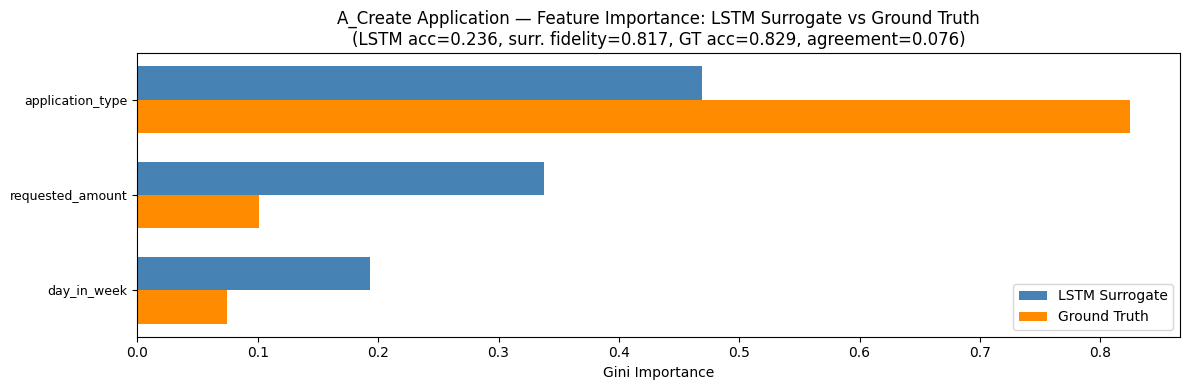

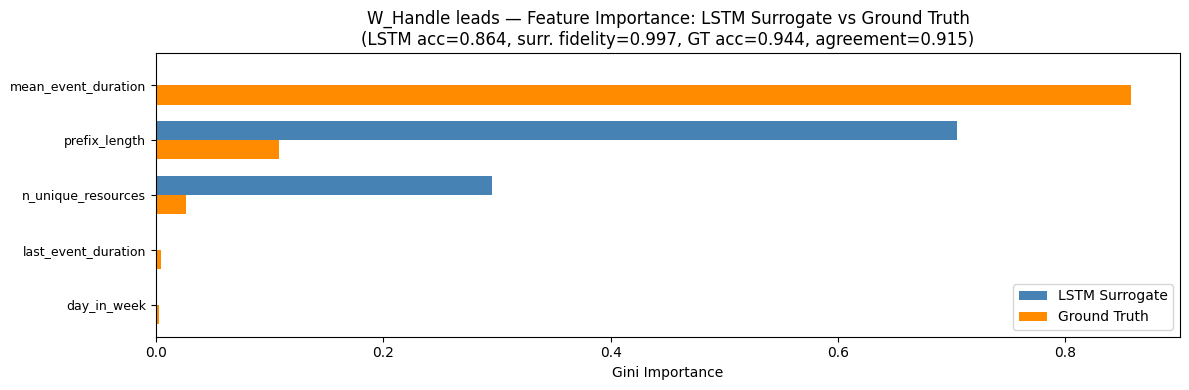

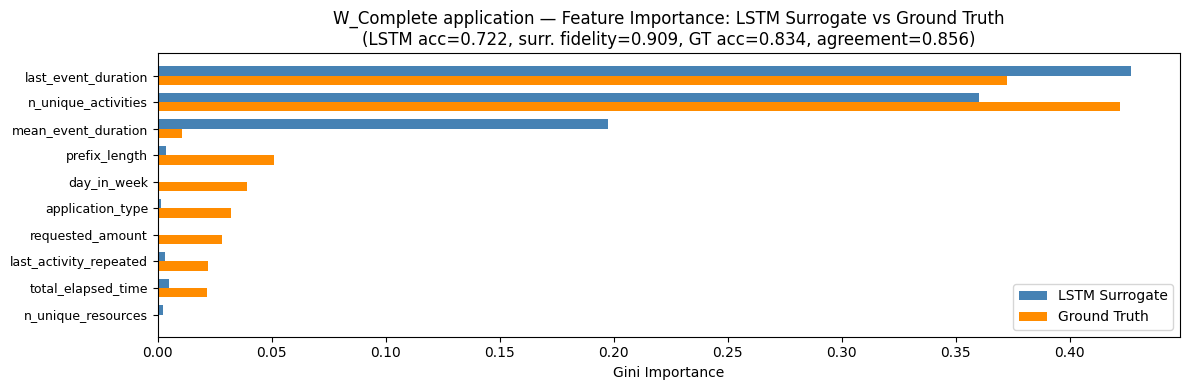

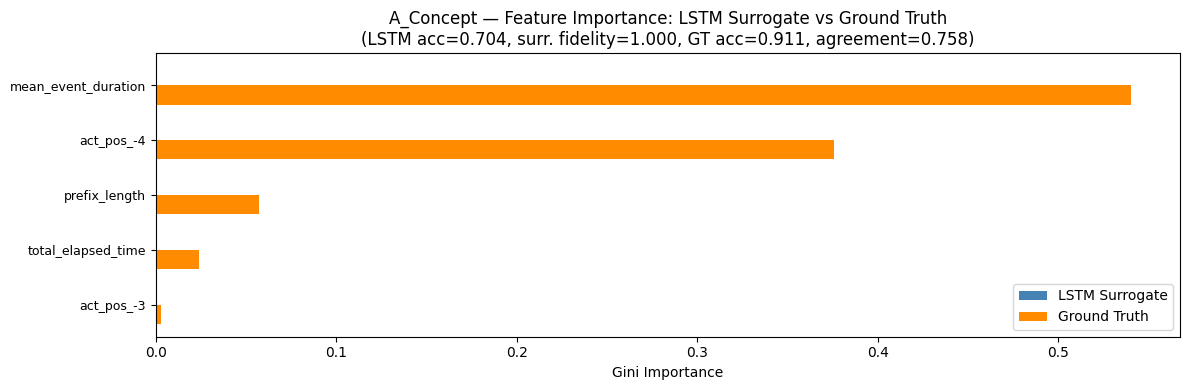

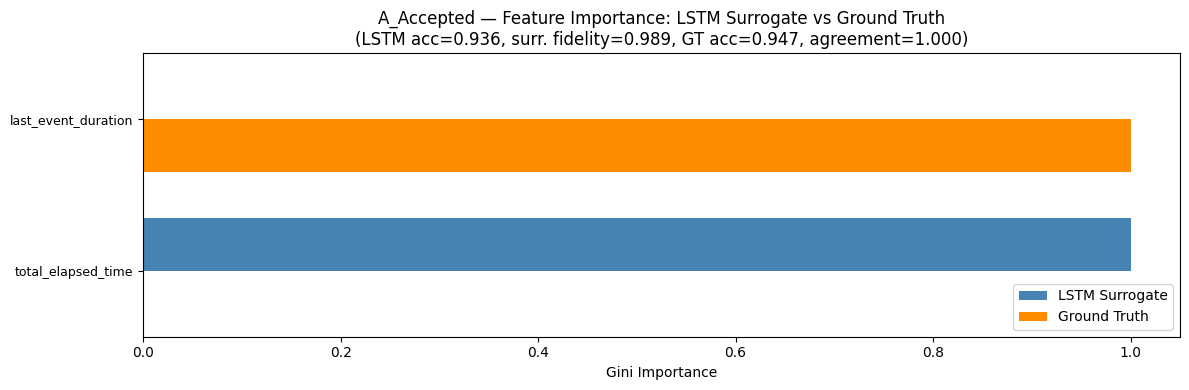

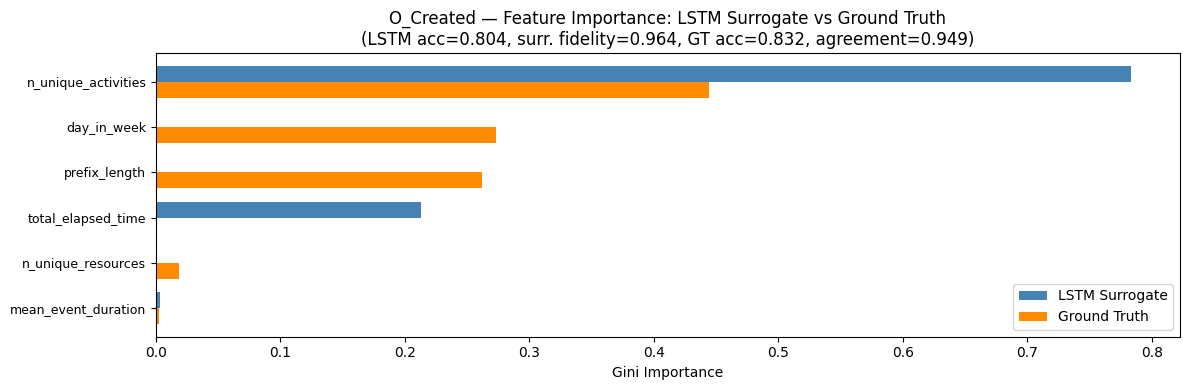

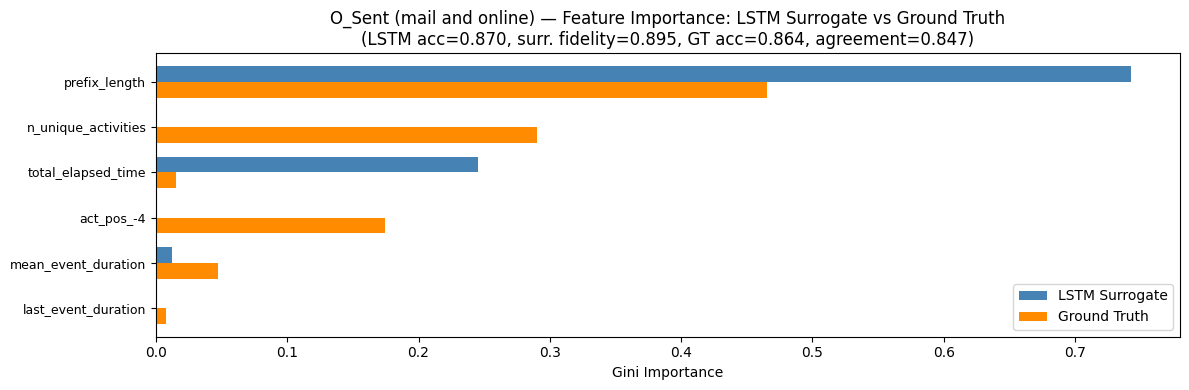

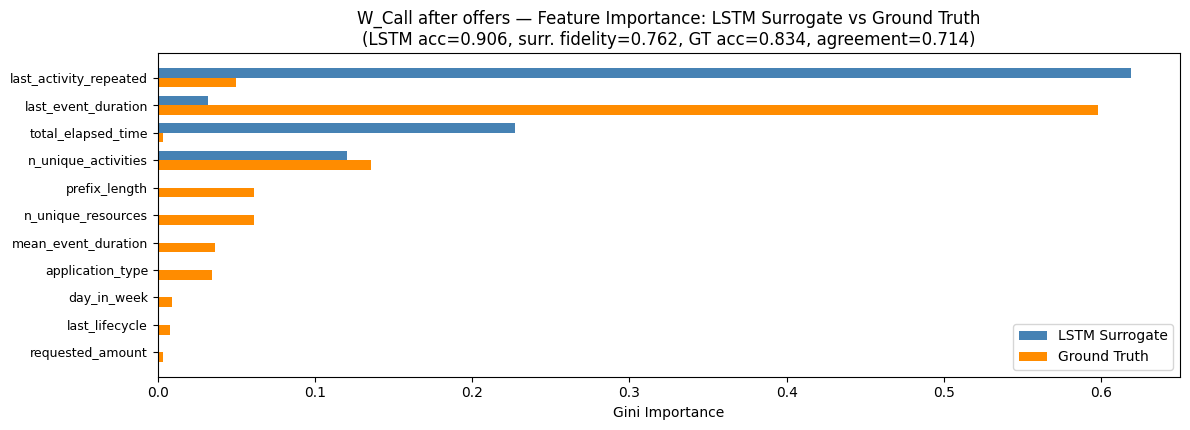

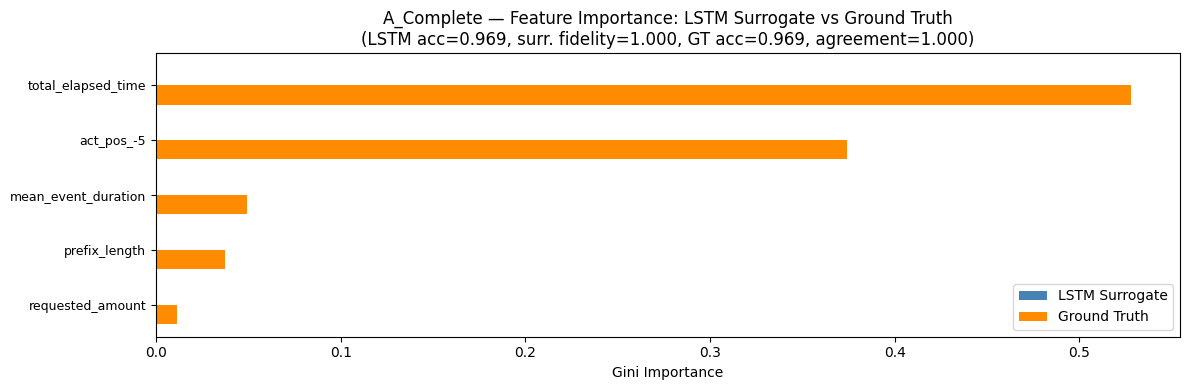

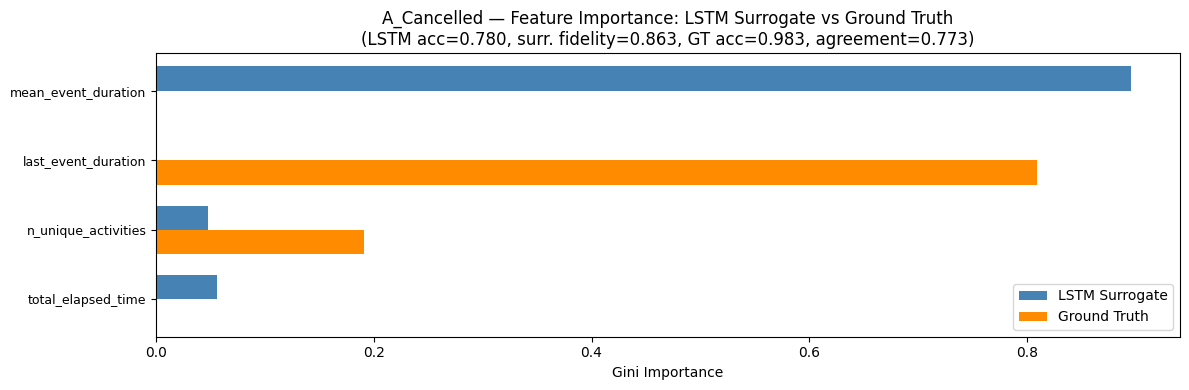

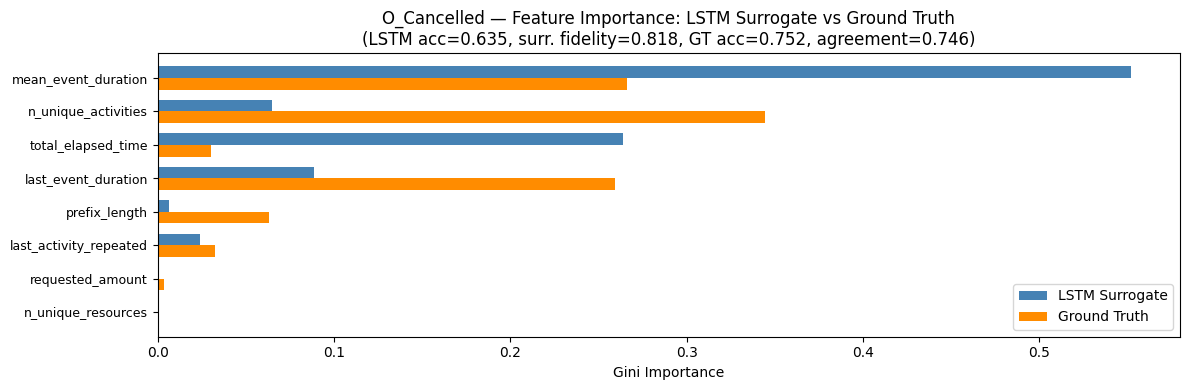

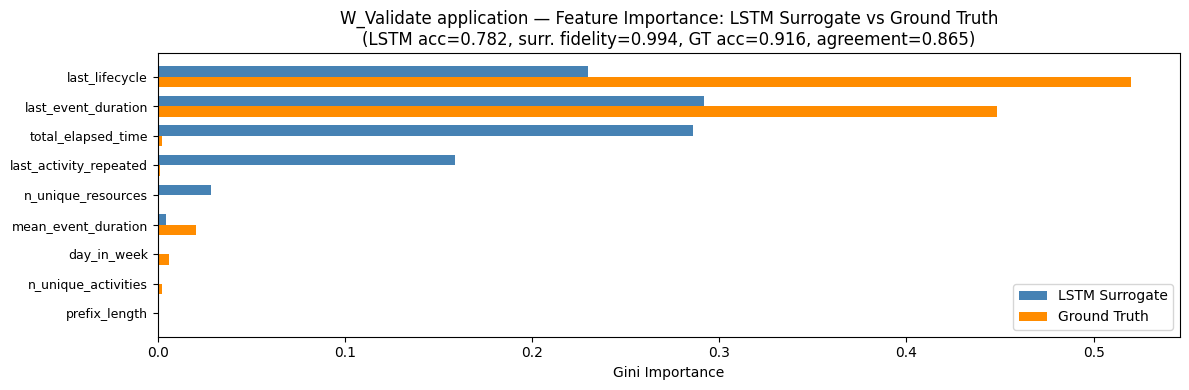

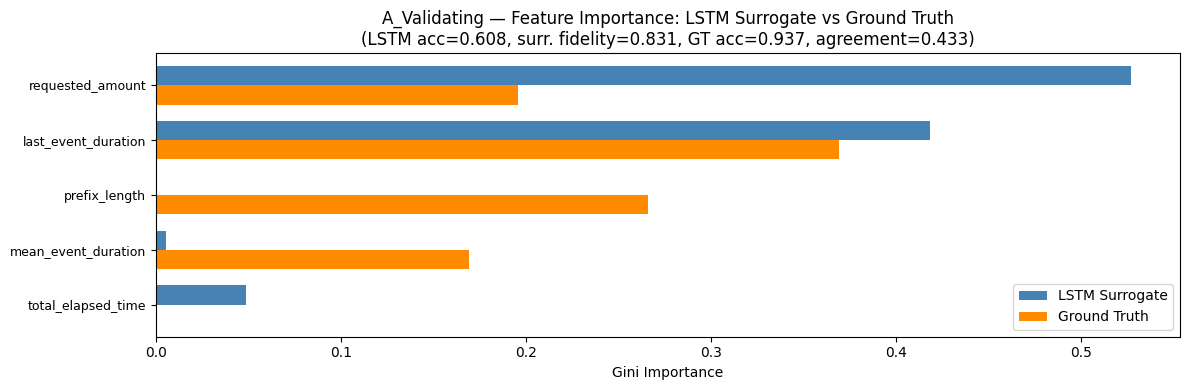

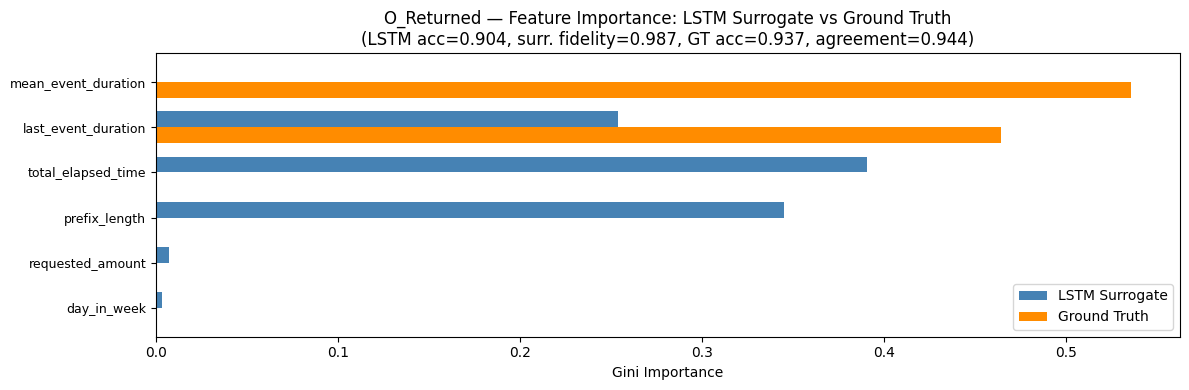

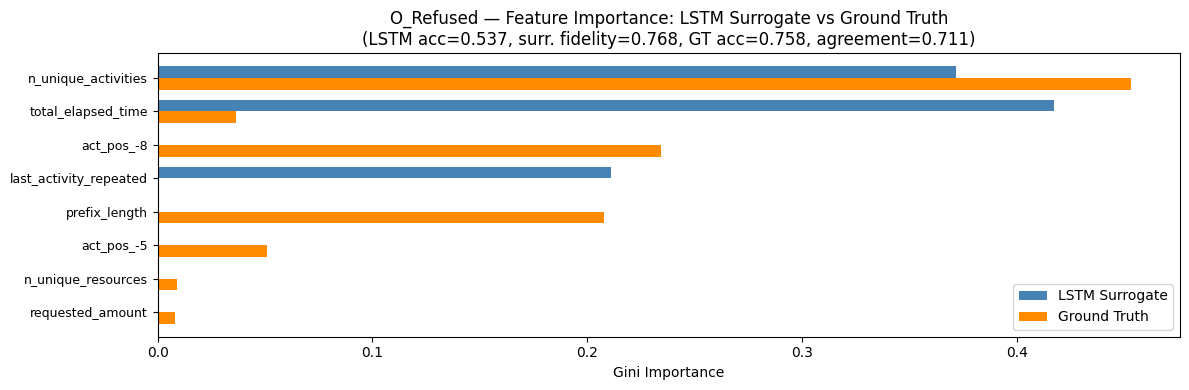

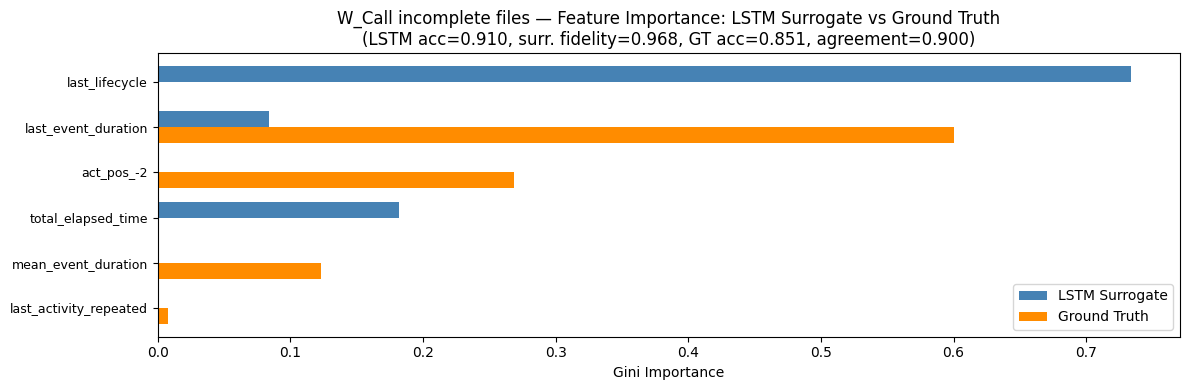

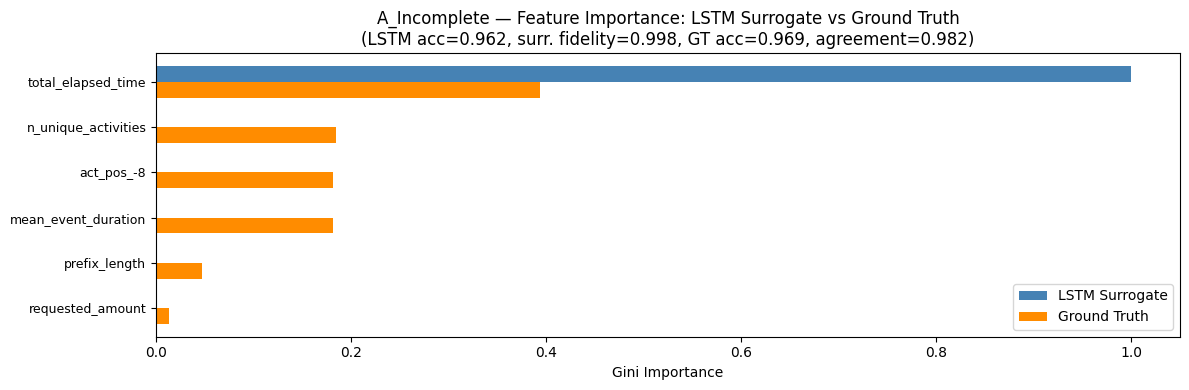

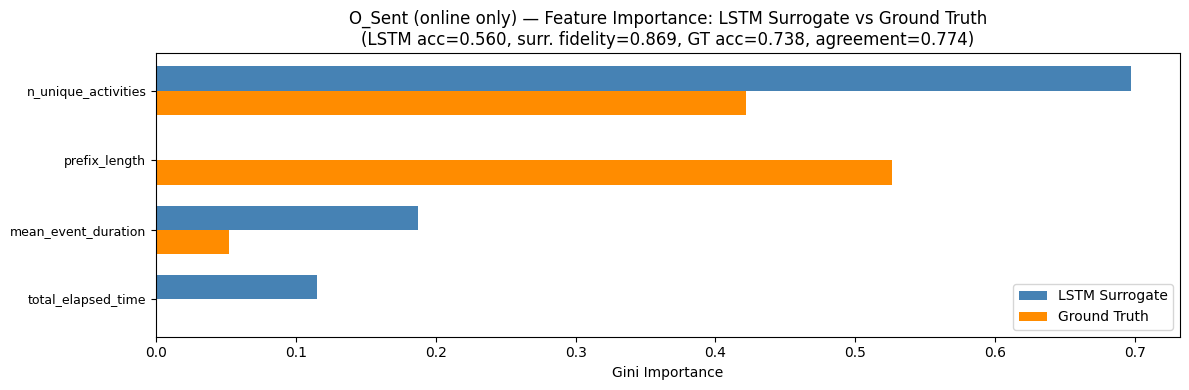

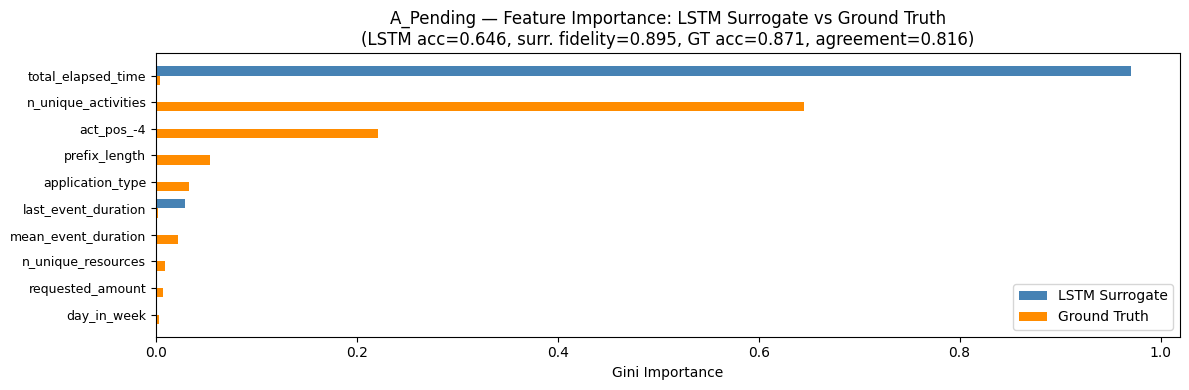

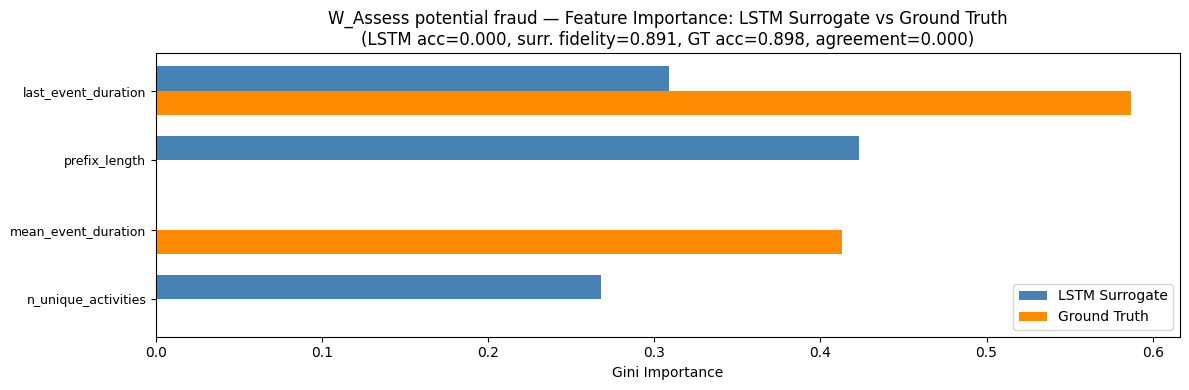

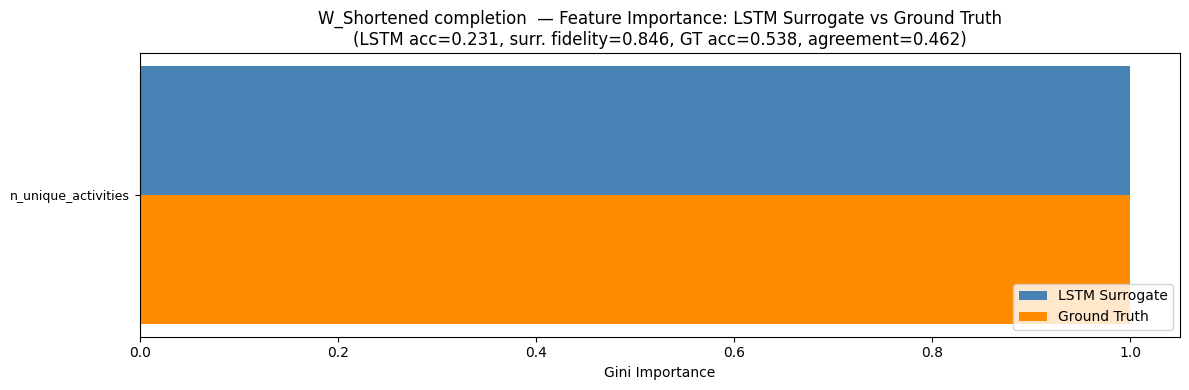

In [ ]:
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_

    # Only show features with non-zero importance in either tree
    mask = (imp_lstm > 0) | (imp_gt > 0)
    fn_nz = [f for f, m in zip(fn, mask) if m]
    imp_lstm_nz = imp_lstm[mask]
    imp_gt_nz = imp_gt[mask]

    # Sort by max importance across both
    order = np.argsort(np.maximum(imp_lstm_nz, imp_gt_nz))[::-1]
    fn_nz = [fn_nz[i] for i in order]
    imp_lstm_nz = imp_lstm_nz[order]
    imp_gt_nz = imp_gt_nz[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(fn_nz) * 0.4)))
    y_pos = np.arange(len(fn_nz))
    bar_h = 0.35

    ax.barh(y_pos - bar_h / 2, imp_lstm_nz, bar_h, label='LSTM Surrogate', color='steelblue')
    ax.barh(y_pos + bar_h / 2, imp_gt_nz, bar_h, label='Ground Truth', color='darkorange')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_nz, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Gini Importance')
    ax.set_title(f'{gateway_act} — Feature Importance: LSTM Surrogate vs Ground Truth\n'
                 f'(LSTM acc={gr["lstm_accuracy"]:.3f}, '
                 f'surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
                 f'GT acc={gr["gt_accuracy"]:.3f}, '
                 f'agreement={gr["agreement"]:.3f})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Side-by-side tree visualizations

Trees are capped at **depth 4** for readability. Full decision logic is in the
if/then rules section below. Split conditions show decoded category names.

In [ ]:
# C4.5 trees have multi-way splits and cannot use sklearn's plot_tree.
# Instead, print the tree as readable rules.

def print_tree_rules(clf, label, max_rules=15):
    rules = clf.extract_rules()
    print(f'\n  {label} ({len(rules)} rules, showing top {min(max_rules, len(rules))}):')
    print(f'  {"─" * 70}')
    for i, rule in enumerate(rules[:max_rules]):
        conds = '\n      AND '.join(rule['conditions'])
        print(f'  Rule {i+1} (n={rule["n_samples"]}, {rule["confidence"]:.0%} confidence):')
        print(f'    IF  {conds}')
        print(f'    THEN -> {rule["prediction"]}')
        print()


for gateway_act, gr in gateway_results.items():
    print(f'{"=" * 80}')
    print(f'GATEWAY: {gateway_act}')
    print_tree_rules(gr['clf_lstm'], 'LSTM Surrogate (C4.5)')
    print_tree_rules(gr['clf_gt'], 'Ground Truth (C4.5)')

GATEWAY: A_Create Application

  LSTM Surrogate (C4.5) (8 rules, showing top 8):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=3790, 77% confidence):
    IF  application_type = New credit
      AND requested_amount > 4250
      AND day_in_week <= 5.5
    THEN -> W_Handle leads

  Rule 2 (n=363, 100% confidence):
    IF  application_type = New credit
      AND requested_amount > 4250
      AND day_in_week > 5.5
    THEN -> W_Handle leads

  Rule 3 (n=269, 87% confidence):
    IF  application_type = New credit
      AND requested_amount <= 4250
      AND day_in_week <= 3.5
    THEN -> W_Complete application

  Rule 4 (n=219, 100% confidence):
    IF  application_type = Limit raise
      AND requested_amount > 2500
      AND day_in_week > 1.5
    THEN -> W_Complete application

  Rule 5 (n=186, 98% confidence):
    IF  application_type = Limit raise
      AND requested_amount > 2500
      AND day_in_week <= 1.5
    THEN -> W_Complete application

  R

## Decision rules as readable if/then statements

Each leaf becomes one rule. Conditions along the path from root to leaf are
combined with AND. Rules are sorted by sample count (most common decisions
first).

In [ ]:
# Rule extraction is now built into C45Classifier.extract_rules()
# (printed in the cell above)

## Confusion: surrogate predictions vs ground truth predictions

Where do the two trees disagree? Each cell shows how many test samples the
LSTM surrogate assigned to one branch while the ground truth tree assigned
to another.

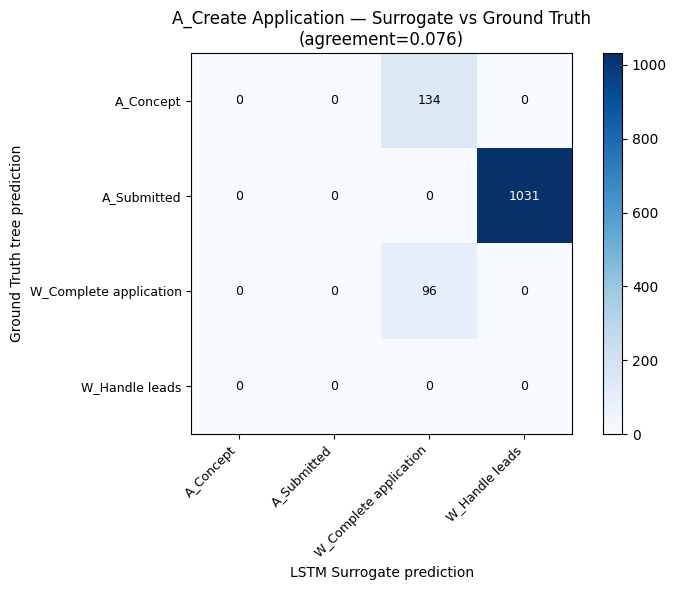

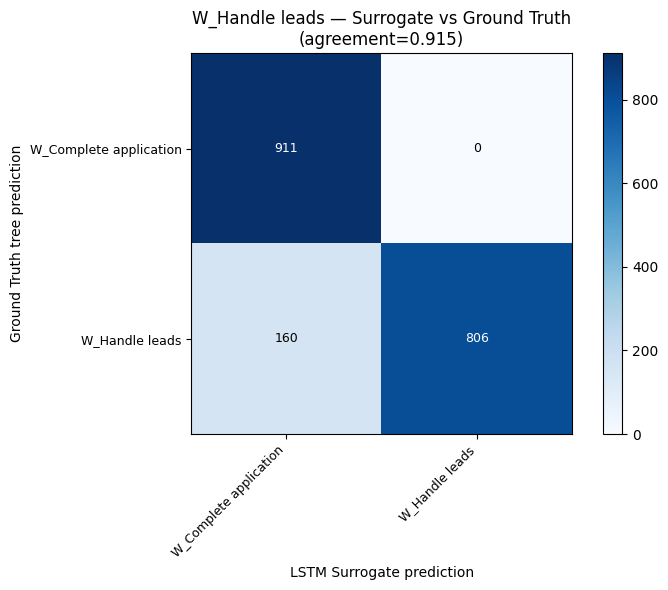

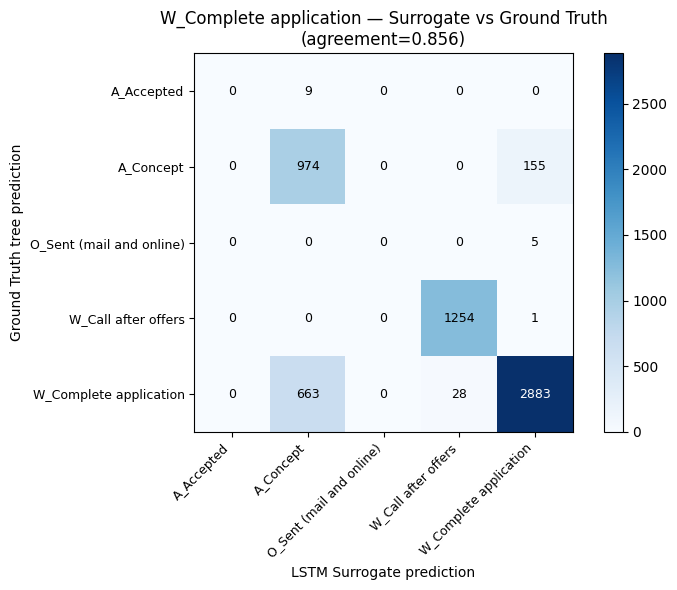

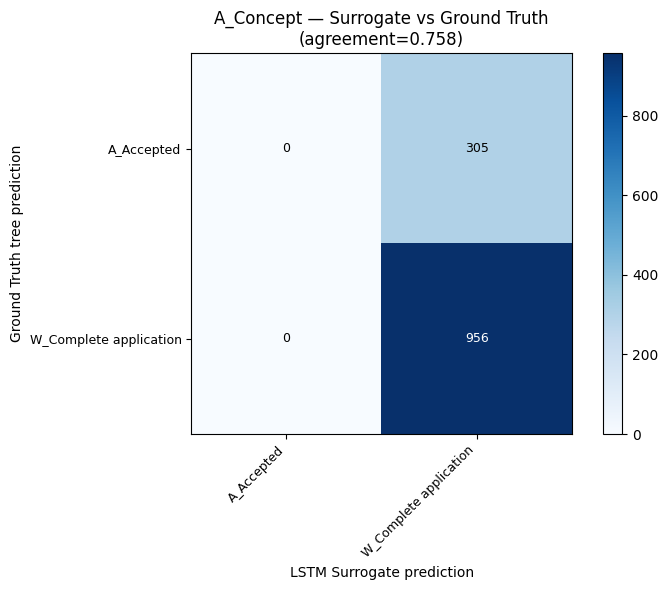

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


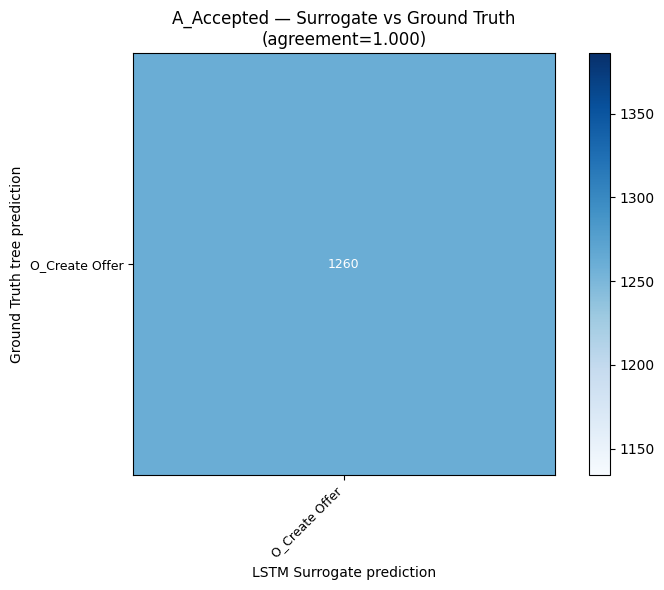

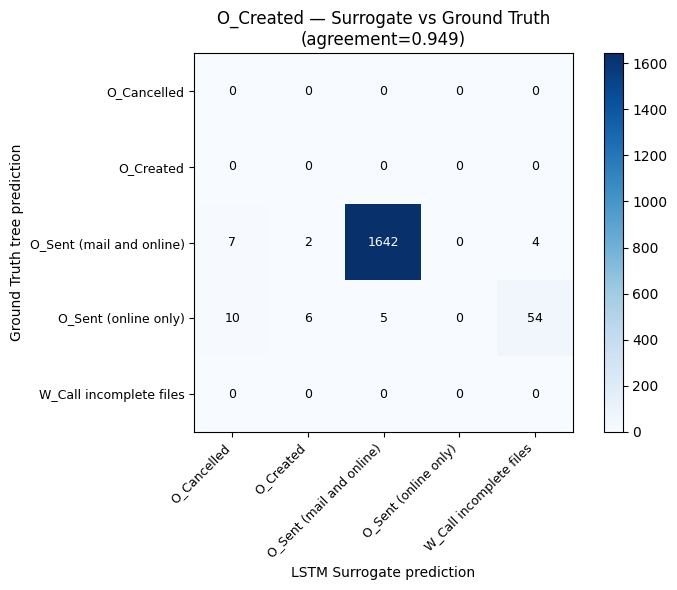

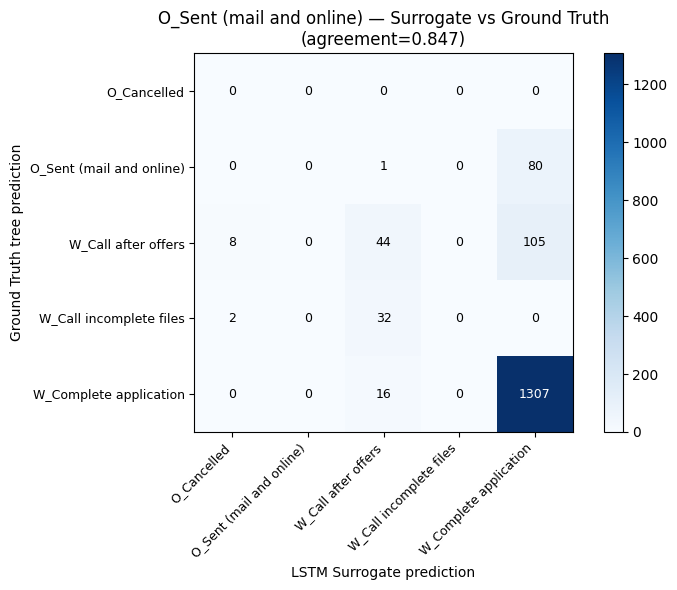

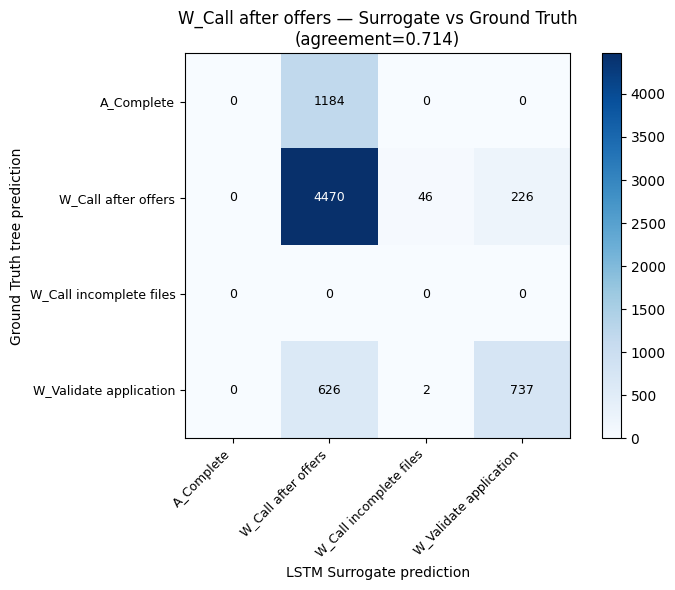

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


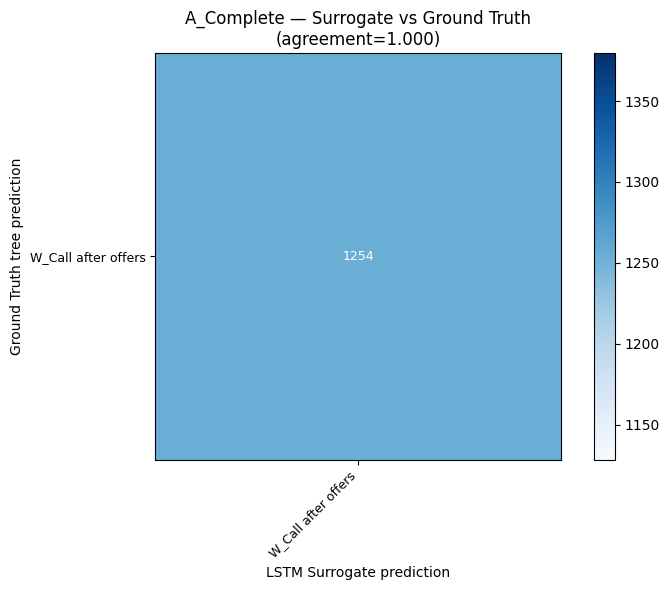

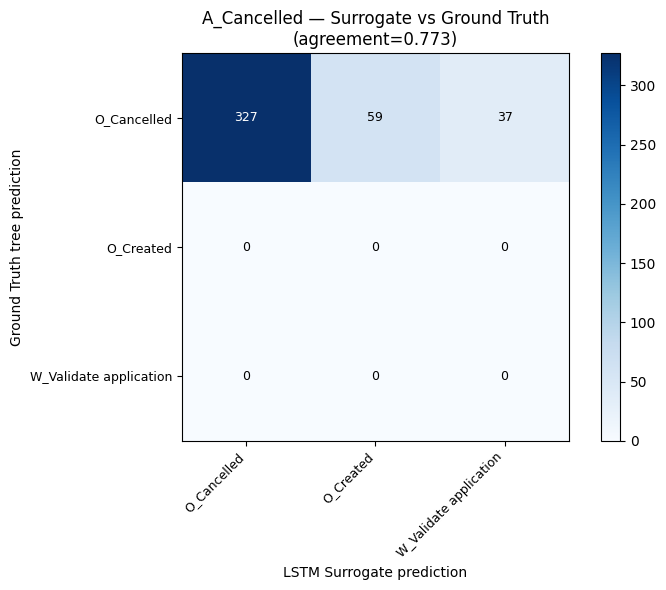

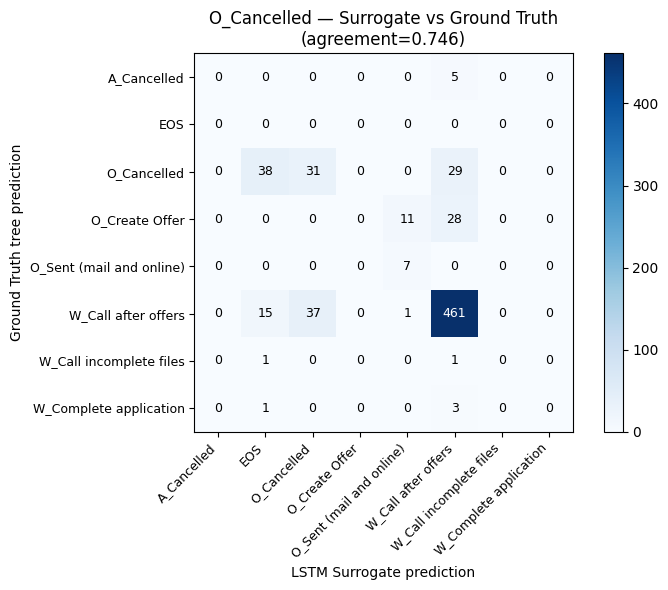

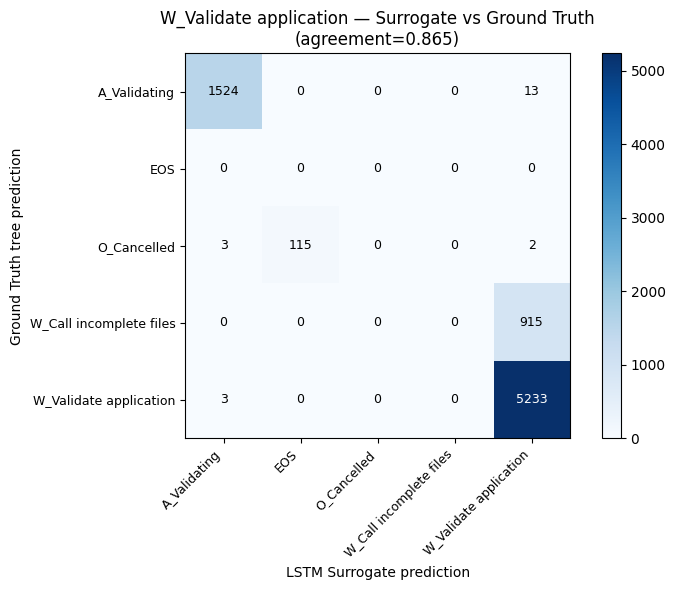

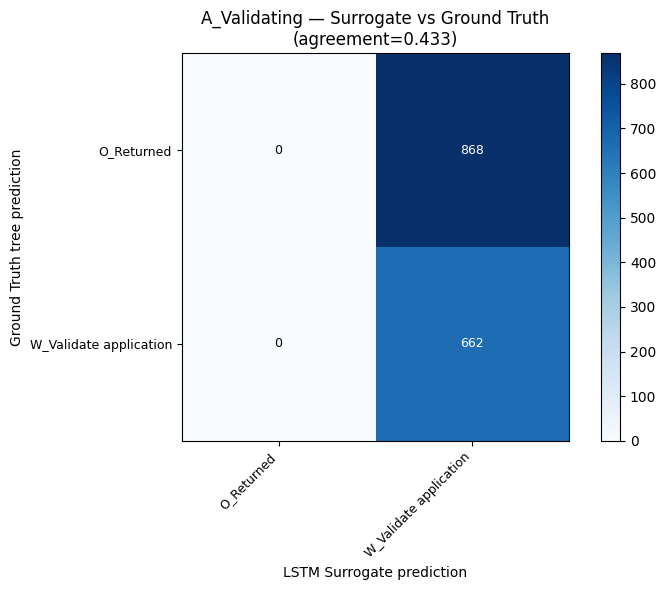

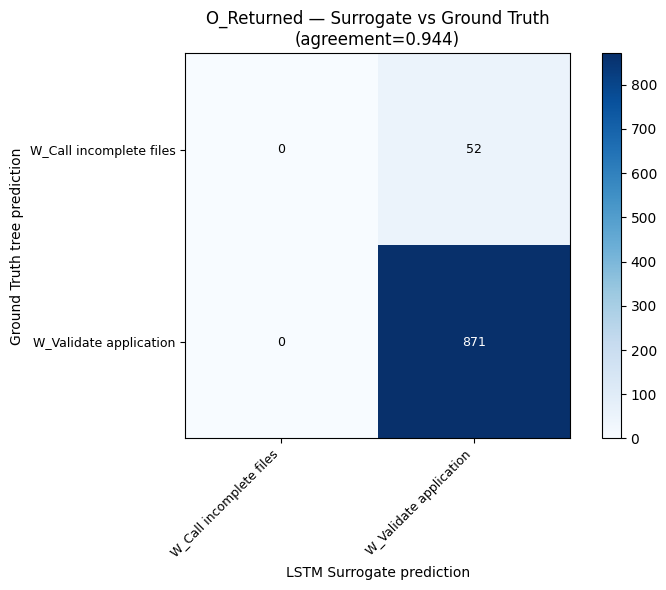

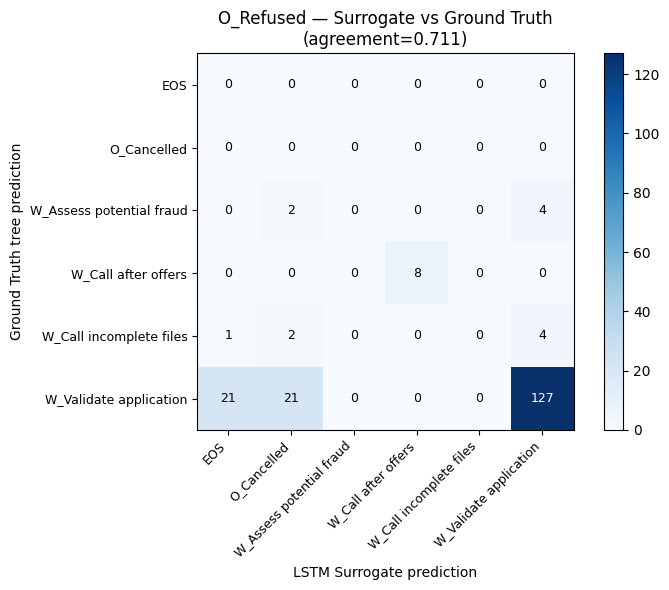

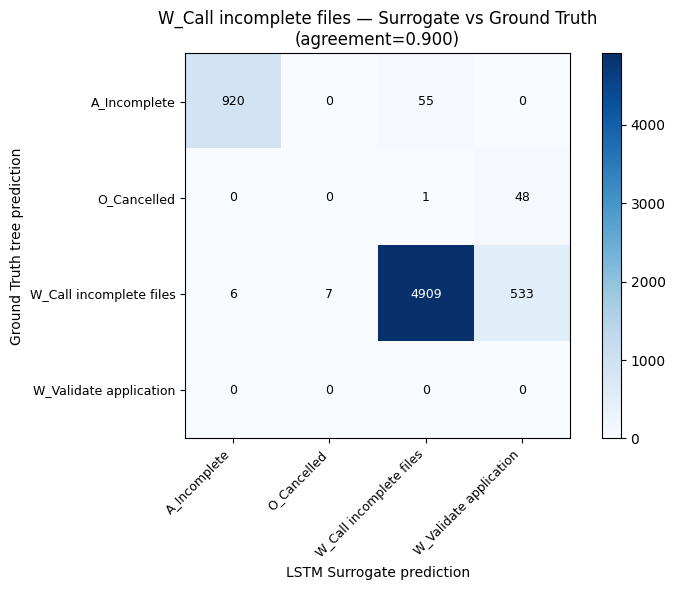

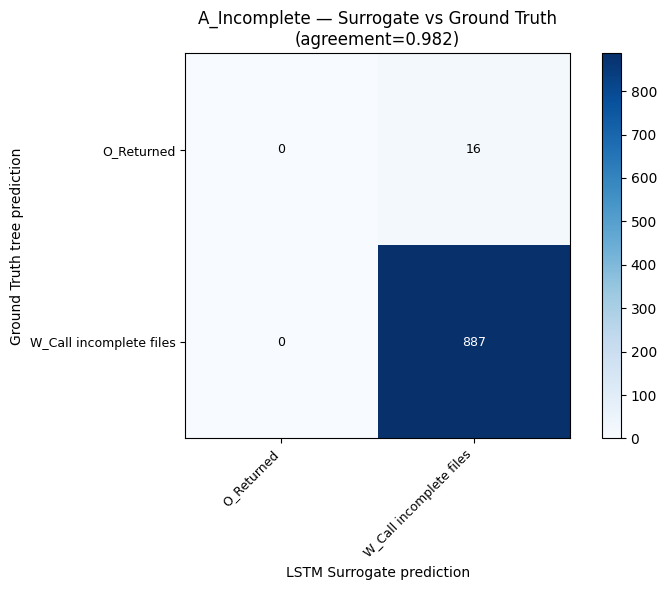

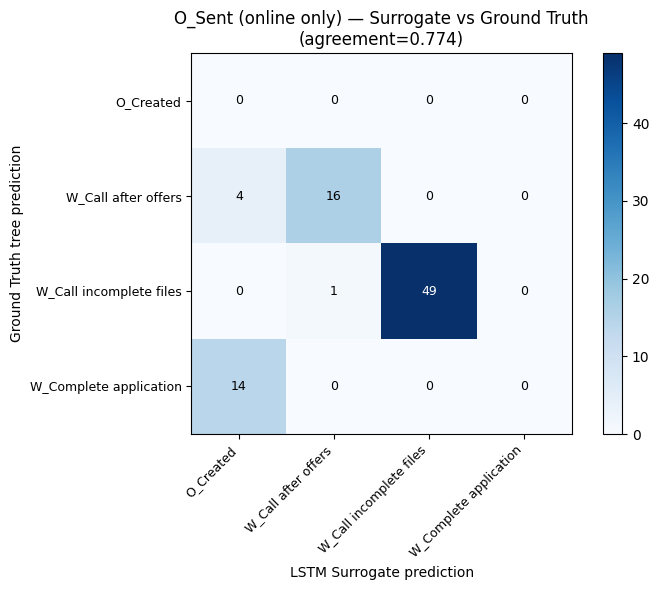

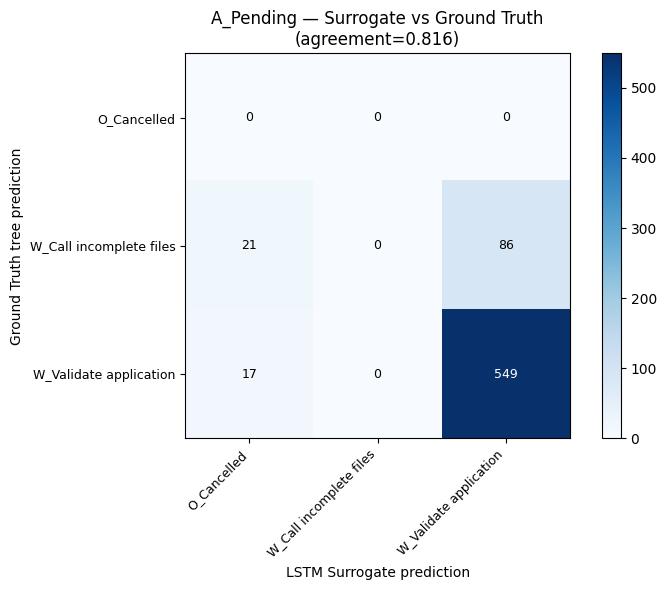

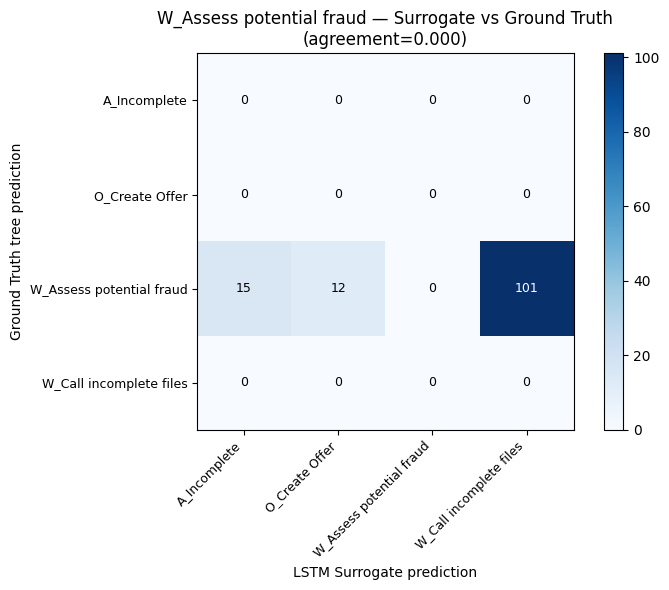

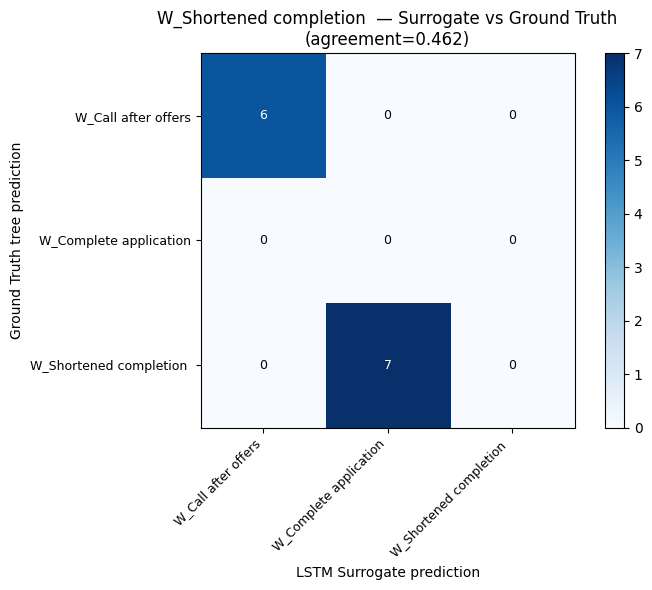

In [ ]:
for gateway_act, gr in gateway_results.items():
    y_surr = gr['clf_lstm'].predict(gr['X_test'])
    y_gt = gr['clf_gt'].predict(gr['X_test'])

    labels = sorted(set(y_surr) | set(y_gt))
    cm = confusion_matrix(y_gt, y_surr, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('LSTM Surrogate prediction')
    ax.set_ylabel('Ground Truth tree prediction')
    ax.set_title(f'{gateway_act} — Surrogate vs Ground Truth\n(agreement={gr["agreement"]:.3f})')
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

## Deep dive: disagreement analysis

For the gateway with the lowest agreement rate, examine individual test cases
where the surrogate and ground truth trees predict different branches. Shows
what the LSTM actually predicted vs what happened, and which features are at
play.

In [ ]:
# Find gateway with lowest agreement
worst_gateway = min(gateway_results, key=lambda g: gateway_results[g]['agreement'])
gr = gateway_results[worst_gateway]
print(f'Deepest disagreement: {worst_gateway} (agreement={gr["agreement"]:.3f})\n')

y_surr = gr['clf_lstm'].predict(gr['X_test'])
y_gt_pred = gr['clf_gt'].predict(gr['X_test'])
disagree_mask = y_surr != y_gt_pred
disagree_indices = np.where(disagree_mask)[0]

n_show = min(8, len(disagree_indices))
rng = np.random.RandomState(42)
show_indices = rng.choice(disagree_indices, size=n_show, replace=False) if len(disagree_indices) > 0 else []

for idx in show_indices:
    sample = gr['X_test'].iloc[idx]
    lstm_pred = gr['y_lstm_test'].iloc[idx] if hasattr(gr['y_lstm_test'], 'iloc') else gr['y_lstm_test'][idx]
    actual = gr['y_actual_test'].iloc[idx] if hasattr(gr['y_actual_test'], 'iloc') else gr['y_actual_test'][idx]
    surr_pred = y_surr[idx]
    gt_pred = y_gt_pred[idx]

    print(f'{"=" * 80}')
    print(f'Actual next: {actual} | LSTM predicted: {lstm_pred}')
    print(f'Surrogate tree: {surr_pred} | GT tree: {gt_pred}')

    print(f'\n  Surrogate path:')
    for i, step in enumerate(gr['clf_lstm'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {surr_pred}')

    print(f'\n  GT path:')
    for i, step in enumerate(gr['clf_gt'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {gt_pred}')
    print()

Deepest disagreement: W_Assess potential fraud (agreement=0.000)

Actual next: W_Assess potential fraud | LSTM predicted: W_Call incomplete files
Surrogate tree: W_Call incomplete files | GT tree: W_Assess potential fraud

  Surrogate path:
    1. prefix_length = 29 > 19.5
    2. n_unique_activities = 15 > 12.5
    3. last_event_duration = 11.35 <= 2.619e+05
    4. last_event_duration = 11.35 > 0.008758
    -> W_Call incomplete files

  GT path:
    1. mean_event_duration = 2.425e+04 > 1.215e+04
    2. last_event_duration = 11.35 > 7.921
    3. last_event_duration = 11.35 <= 18.98
    -> W_Assess potential fraud

Actual next: W_Assess potential fraud | LSTM predicted: W_Call incomplete files
Surrogate tree: W_Call incomplete files | GT tree: W_Assess potential fraud

  Surrogate path:
    1. prefix_length = 59 > 19.5
    2. n_unique_activities = 15 > 12.5
    3. last_event_duration = 6.773e+04 <= 2.619e+05
    4. last_event_duration = 6.773e+04 > 0.008758
    -> W_Call incomplete files

## Depth sweep comparison

Shows how validation fidelity/accuracy evolves with tree depth for both
trees at each gateway. These curves are used only for depth selection;
test-set performance is reported once in the summary table. Helps judge
the interpretability-accuracy tradeoff.

In [ ]:
for gateway_act, gr in gateway_results.items():
    lstm_sw = gr['lstm_sweep']
    gt_sw = gr['gt_sweep']

    depths_label = [str(r['depth']) if r['depth'] is not None else 'None' for r in lstm_sw]
    lstm_val = [r['val'] for r in lstm_sw]
    gt_val = [r['val'] for r in gt_sw]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(depths_label))
    ax.plot(x, lstm_val, 'o-', color='steelblue', label='LSTM Surrogate (fidelity)')
    ax.plot(x, gt_val, 's-', color='darkorange', label='Ground Truth (accuracy)')
    ax.set_xticks(x)
    ax.set_xticklabels(depths_label)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Validation score')
    ax.set_title(f'{gateway_act} — Depth sweep')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Table
    rows = []
    for ls, gs in zip(lstm_sw, gt_sw):
        rows.append({
            'depth': ls['depth'] if ls['depth'] is not None else 'None',
            'surr_train': f'{ls["train"]:.3f}',
            'surr_val': f'{ls["val"]:.3f}',
            'surr_leaves': ls['clf'].get_n_leaves(),
            'gt_train': f'{gs["train"]:.3f}',
            'gt_val': f'{gs["val"]:.3f}',
            'gt_leaves': gs['clf'].get_n_leaves(),
        })
    display(pd.DataFrame(rows))